# uSERS-Net Figure Validation

## Goal

Recompute panels (A)–(C) from the archived out-of-fold predictions and compare every reported value with the reference screenshot. Run the cells from top to bottom. Assertions stop execution if a value no longer matches.

## Context & Methods

- Source artifact: `results/legacy/hidden_2026-05-19/top_level/runs/2026-05-11_usersnet_alpha0.8_ovr_roc/all_models_oof.npz`
- Panel A: binary ROC curves, 1,000 deterministic bootstrap samples, and the uSERS-Net confusion matrix at the Youden threshold.
- Panel B: one-vs-rest ROC curves for seven cancer types.
- Panel C: row-normalized seven-class confusion matrix among cancer samples.

### Key Assumptions

The archived NPZ is the authoritative prediction artifact used by the May 2026 figure scripts. Class indices follow the original model order: PRC, BRC, OVC, LC, CRC, PAC, BLC.

> **Hospital-confound disclaimer:** the Cancer Screening AUC may reflect hospital/source differences because non-cancer and cancer cohorts were collected at different hospitals. This notebook verifies numerical reproduction; it does not establish cross-hospital generalization.

In [1]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from IPython.display import Markdown, display
from matplotlib.colors import to_rgba
from numpy.typing import NDArray
from sklearn.metrics import auc, confusion_matrix, f1_score, roc_curve

FloatArray = NDArray[np.float64]
IntArray = NDArray[np.int64]

working_directory = Path.cwd().resolve()
project_root = next(
    candidate
    for candidate in (working_directory, *working_directory.parents)
    if (candidate / "pyproject.toml").is_file()
)
data_path = (
    project_root
    / "results/legacy/hidden_2026-05-19/top_level/runs"
    / "2026-05-11_usersnet_alpha0.8_ovr_roc/all_models_oof.npz"
)
assert data_path.is_file(), f"Prediction artifact not found: {data_path}"
print(f"NumPy {np.__version__} | scikit-learn {sklearn.__version__} | Matplotlib {matplotlib.__version__}")
print(f"Source: {data_path.relative_to(project_root)}")

NumPy 2.2.6 | scikit-learn 1.7.2 | Matplotlib 3.10.9
Source: results/legacy/hidden_2026-05-19/top_level/runs/2026-05-11_usersnet_alpha0.8_ovr_roc/all_models_oof.npz


## Data

### 1. Load and validate the archived predictions

In [2]:
model_names = (
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "CNN1D",
    "ResNet18",
    "uSERS-Net",
)

with np.load(data_path) as archive:
    binary_labels: IntArray = np.asarray(archive["bl"], dtype=np.int64)
    cancer_labels: IntArray = np.asarray(archive["ctl"], dtype=np.int64)
    binary_scores = {
        name: np.asarray(archive[f"{name}_bp"], dtype=np.float64)
        for name in model_names
    }
    cancer_scores: FloatArray = np.asarray(archive["uSERS-Net_cl"], dtype=np.float64)

assert binary_labels.shape == (1628,)
assert cancer_labels.shape == (1628,)
assert cancer_scores.shape == (1628, 7)
assert np.array_equal(np.bincount(binary_labels), np.array([429, 1199]))

display(
    Markdown(
        f"**Loaded {binary_labels.size:,} OOF samples:** "
        f"{int((binary_labels == 0).sum()):,} non-cancer and "
        f"{int((binary_labels == 1).sum()):,} cancer. Input shape checks passed."
    )
)

**Loaded 1,628 OOF samples:** 429 non-cancer and 1,199 cancer. Input shape checks passed.

## Results

### 2. Validate panel A: binary ROC and confusion matrix

In [3]:
def bootstrap_auc_ci(
    labels: IntArray,
    scores: FloatArray,
    *,
    samples: int = 1000,
    seed: int = 42,
) -> tuple[float, float]:
    """Return the deterministic percentile bootstrap interval used in the source figure."""
    generator = np.random.default_rng(seed)
    bootstrapped_aucs: list[float] = []
    for _ in range(samples):
        indices = generator.integers(0, labels.size, labels.size)
        sampled_labels = labels[indices]
        if sampled_labels.sum() == 0 or sampled_labels.sum() == sampled_labels.size:
            continue
        false_positive_rate, true_positive_rate, _ = roc_curve(
            sampled_labels, scores[indices]
        )
        bootstrapped_aucs.append(float(auc(false_positive_rate, true_positive_rate)))
    lower, upper = np.percentile(np.asarray(bootstrapped_aucs), [2.5, 97.5])
    return float(lower), float(upper)

expected_binary = {
    "Logistic Regression": (0.980, 0.973, 0.986),
    "Random Forest": (0.941, 0.929, 0.953),
    "XGBoost": (0.965, 0.956, 0.973),
    "CNN1D": (0.855, 0.835, 0.873),
    "ResNet18": (0.962, 0.953, 0.971),
    "uSERS-Net": (0.983, 0.977, 0.988),
}
binary_results = {}
for name in model_names:
    valid = ~np.isnan(binary_scores[name])
    false_positive_rate, true_positive_rate, _ = roc_curve(
        binary_labels[valid], binary_scores[name][valid]
    )
    auc_value = float(auc(false_positive_rate, true_positive_rate))
    lower, upper = bootstrap_auc_ci(binary_labels[valid], binary_scores[name][valid])
    binary_results[name] = (false_positive_rate, true_positive_rate, auc_value, lower, upper)
    assert (round(auc_value, 3), round(lower, 3), round(upper, 3)) == expected_binary[name]

usersnet_fpr, usersnet_tpr, usersnet_thresholds = roc_curve(
    binary_labels, binary_scores["uSERS-Net"]
)
youden_threshold = float(usersnet_thresholds[np.argmax(usersnet_tpr - usersnet_fpr)])
binary_predictions = (binary_scores["uSERS-Net"] >= youden_threshold).astype(np.int64)
binary_confusion = confusion_matrix(binary_labels, binary_predictions)
expected_binary_confusion = np.array([[395, 34], [39, 1160]])
assert np.array_equal(binary_confusion, expected_binary_confusion)

binary_rows = ["| Model | AUC | 95% bootstrap CI | Match |", "|---|---:|---:|:---:|"]
for name in model_names:
    _, _, auc_value, lower, upper = binary_results[name]
    binary_rows.append(f"| {name} | {auc_value:.3f} | [{lower:.3f}, {upper:.3f}] | ✓ |")
display(Markdown("\n".join(binary_rows)))
display(Markdown(f"**Youden threshold:** `{youden_threshold:.6f}`  \n**Confusion matrix:** `{binary_confusion.tolist()}` ✓"))

| Model | AUC | 95% bootstrap CI | Match |
|---|---:|---:|:---:|
| Logistic Regression | 0.980 | [0.973, 0.986] | ✓ |
| Random Forest | 0.941 | [0.929, 0.953] | ✓ |
| XGBoost | 0.965 | [0.956, 0.973] | ✓ |
| CNN1D | 0.855 | [0.835, 0.873] | ✓ |
| ResNet18 | 0.962 | [0.953, 0.971] | ✓ |
| uSERS-Net | 0.983 | [0.977, 0.988] | ✓ |

**Youden threshold:** `0.365387`  
**Confusion matrix:** `[[395, 34], [39, 1160]]` ✓

### 3. Validate panel B: seven one-vs-rest ROC curves

In [4]:
cancer_order = ("CRC", "LC", "BLC", "PRC", "PAC", "OVC", "BRC")
cancer_index = {"PRC": 0, "BRC": 1, "OVC": 2, "LC": 3, "CRC": 4, "PAC": 5, "BLC": 6}
expected_cancer_auc = {
    "CRC": (0.986, 300),
    "LC": (0.972, 300),
    "BLC": (0.996, 299),
    "PRC": (0.981, 100),
    "PAC": (0.948, 100),
    "OVC": (0.991, 70),
    "BRC": (0.985, 30),
}
cancer_roc_results = {}
cancer_rows = ["| Cancer | n | OvR AUC | Match |", "|---|---:|---:|:---:|"]
for cancer in cancer_order:
    class_index = cancer_index[cancer]
    one_vs_rest = (cancer_labels == class_index).astype(np.int64)
    false_positive_rate, true_positive_rate, _ = roc_curve(
        one_vs_rest, cancer_scores[:, class_index]
    )
    auc_value = float(auc(false_positive_rate, true_positive_rate))
    sample_count = int(one_vs_rest.sum())
    cancer_roc_results[cancer] = (false_positive_rate, true_positive_rate, auc_value, sample_count)
    assert (round(auc_value, 3), sample_count) == expected_cancer_auc[cancer]
    cancer_rows.append(f"| {cancer} | {sample_count} | {auc_value:.3f} | ✓ |")
display(Markdown("\n".join(cancer_rows)))

| Cancer | n | OvR AUC | Match |
|---|---:|---:|:---:|
| CRC | 300 | 0.986 | ✓ |
| LC | 300 | 0.972 | ✓ |
| BLC | 299 | 0.996 | ✓ |
| PRC | 100 | 0.981 | ✓ |
| PAC | 100 | 0.948 | ✓ |
| OVC | 70 | 0.991 | ✓ |
| BRC | 30 | 0.985 | ✓ |

### 4. Validate panel C: seven-class confusion matrix

In [5]:
cancer_mask = cancer_labels >= 0
ordered_indices = [cancer_index[cancer] for cancer in cancer_order]
predicted_cancer = np.argmax(cancer_scores[cancer_mask], axis=1)
type_confusion = confusion_matrix(
    cancer_labels[cancer_mask], predicted_cancer, labels=ordered_indices
)
expected_type_confusion = np.array(
    [
        [283, 5, 1, 0, 10, 1, 0],
        [4, 278, 1, 3, 3, 4, 7],
        [2, 0, 294, 0, 1, 0, 2],
        [0, 2, 3, 93, 0, 0, 2],
        [14, 1, 7, 0, 76, 0, 2],
        [0, 5, 1, 0, 0, 60, 4],
        [1, 2, 0, 0, 1, 2, 24],
    ]
)
assert np.array_equal(type_confusion, expected_type_confusion)
type_confusion_normalized = type_confusion / type_confusion.sum(axis=1, keepdims=True)
assert np.allclose(
    np.diag(type_confusion_normalized),
    np.array([0.943333, 0.926667, 0.983278, 0.93, 0.76, 0.857143, 0.8]),
    atol=1e-6,
)
matrix_rows = ["| True \\ Pred | " + " | ".join(cancer_order) + " |", "|---|" + "---:|" * 7]
for cancer, row in zip(cancer_order, type_confusion, strict=True):
    matrix_rows.append(f"| {cancer} | " + " | ".join(str(int(value)) for value in row) + " |")
display(Markdown("\n".join(matrix_rows)))
display(Markdown("**Exact count matrix and row-normalized diagonal rates match the screenshot.** ✓"))

| True \ Pred | CRC | LC | BLC | PRC | PAC | OVC | BRC |
|---|---:|---:|---:|---:|---:|---:|---:|
| CRC | 283 | 5 | 1 | 0 | 10 | 1 | 0 |
| LC | 4 | 278 | 1 | 3 | 3 | 4 | 7 |
| BLC | 2 | 0 | 294 | 0 | 1 | 0 | 2 |
| PRC | 0 | 2 | 3 | 93 | 0 | 0 | 2 |
| PAC | 14 | 1 | 7 | 0 | 76 | 0 | 2 |
| OVC | 0 | 5 | 1 | 0 | 0 | 60 | 4 |
| BRC | 1 | 2 | 0 | 0 | 1 | 2 | 24 |

**Exact count matrix and row-normalized diagonal rates match the screenshot.** ✓

### 5. Calculate Cancer Type ID macro F1

In [6]:
per_cancer_f1 = f1_score(
    cancer_labels[cancer_mask],
    predicted_cancer,
    labels=ordered_indices,
    average=None,
    zero_division=0,
)
macro_f1 = float(
    f1_score(
        cancer_labels[cancer_mask],
        predicted_cancer,
        labels=ordered_indices,
        average="macro",
        zero_division=0,
    )
)
assert np.isclose(macro_f1, per_cancer_f1.mean())

f1_rows = ["| Cancer | Support | F1 |", "|---|---:|---:|"]
for cancer, support, score in zip(
    cancer_order, type_confusion.sum(axis=1), per_cancer_f1, strict=True
):
    f1_rows.append(f"| {cancer} | {int(support)} | {score:.3f} |")
f1_rows.append(f"| **Macro average** | **{int(type_confusion.sum())}** | **{macro_f1:.3f}** |")
display(Markdown("\n".join(f1_rows)))
print(f"Cancer Type ID macro F1: {macro_f1:.6f}")

| Cancer | Support | F1 |
|---|---:|---:|
| CRC | 300 | 0.937 |
| LC | 300 | 0.938 |
| BLC | 299 | 0.970 |
| PRC | 100 | 0.949 |
| PAC | 100 | 0.796 |
| OVC | 70 | 0.876 |
| BRC | 30 | 0.676 |
| **Macro average** | **1199** | **0.877** |

Cancer Type ID macro F1: 0.877393


### 6. Reconstruct the combined figure for visual comparison

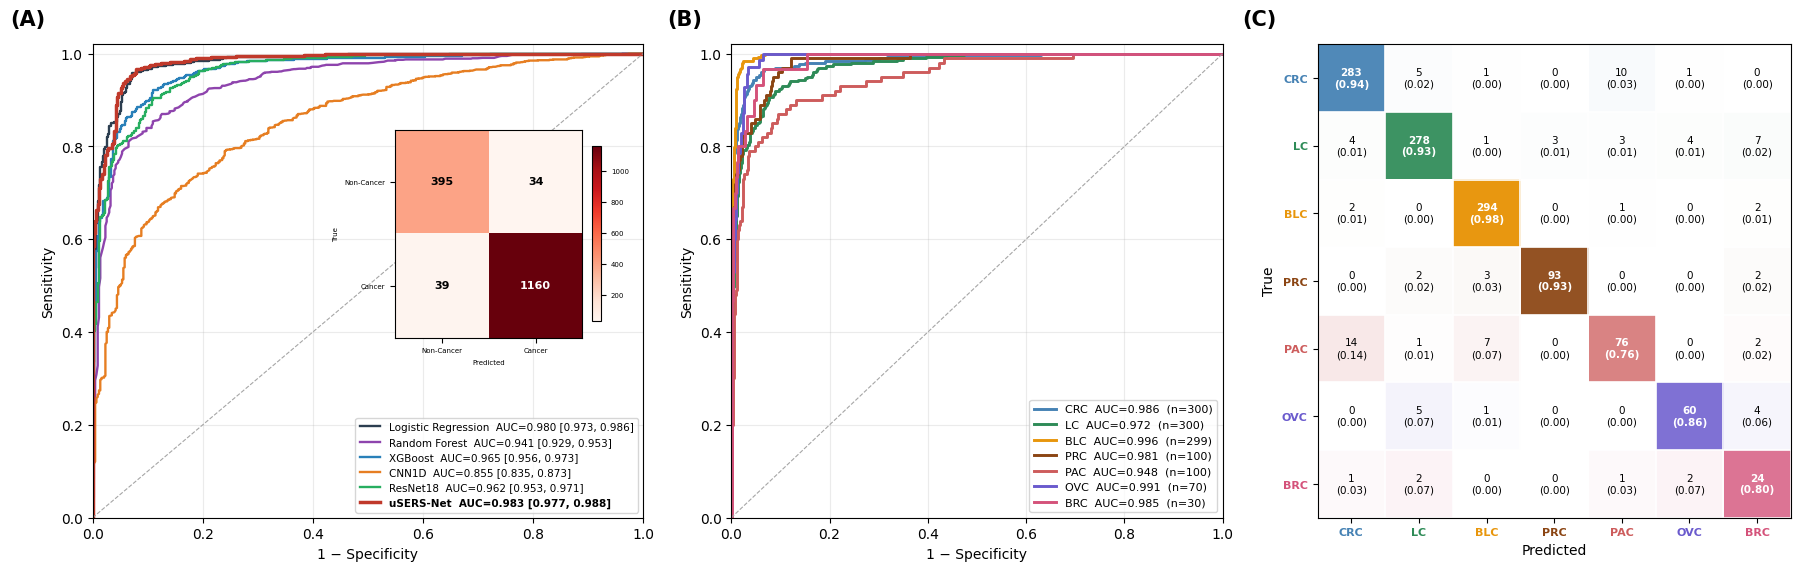

In [7]:
model_colors = {
    "Logistic Regression": "#2C3E50",
    "Random Forest": "#8E44AD",
    "XGBoost": "#2980B9",
    "CNN1D": "#E67E22",
    "ResNet18": "#27AE60",
    "uSERS-Net": "#C0392B",
}
cancer_colors = {
    "CRC": "#4682B4",
    "LC": "#2E8B57",
    "BLC": "#E8960C",
    "PRC": "#8B4513",
    "PAC": "#CD5C5C",
    "OVC": "#6A5ACD",
    "BRC": "#D4527A",
}

figure, (axis_a, axis_b, axis_c) = plt.subplots(
    1, 3, figsize=(18, 5.6), gridspec_kw={"width_ratios": [1.12, 1.0, 1.0]}, layout="constrained"
)

for name in model_names:
    false_positive_rate, true_positive_rate, auc_value, lower, upper = binary_results[name]
    axis_a.plot(
        false_positive_rate,
        true_positive_rate,
        color=model_colors[name],
        linewidth=2.5 if name == "uSERS-Net" else 1.7,
        label=f"{name}  AUC={auc_value:.3f} [{lower:.3f}, {upper:.3f}]",
    )
axis_a.plot([0, 1], [0, 1], "--", color="0.65", linewidth=0.8)
axis_a.set(xlim=(0, 1), ylim=(0, 1.02), xlabel="1 − Specificity", ylabel="Sensitivity")
axis_a.grid(alpha=0.25)
legend_a = axis_a.legend(loc="lower right", fontsize=7.5)
for text_item in legend_a.get_texts():
    if "uSERS-Net" in text_item.get_text():
        text_item.set_fontweight("bold")
axis_a.text(-0.15, 1.04, "(A)", transform=axis_a.transAxes, fontsize=15, fontweight="bold")

inset = axis_a.inset_axes([0.55, 0.38, 0.34, 0.44])
inset_image = inset.imshow(binary_confusion, cmap="Reds", aspect="auto")
for (row_index, column_index), value in np.ndenumerate(binary_confusion):
    inset.text(
        column_index, row_index, str(int(value)), ha="center", va="center",
        fontsize=8, fontweight="bold",
        color="white" if value > binary_confusion.max() * 0.5 else "black",
    )
inset.set_xticks([0, 1], ["Non-Cancer", "Cancer"], fontsize=5)
inset.set_yticks([0, 1], ["Non-Cancer", "Cancer"], fontsize=5)
inset.set_xlabel("Predicted", fontsize=5)
inset.set_ylabel("True", fontsize=5)
colorbar_axis = inset.inset_axes([1.05, 0.08, 0.05, 0.84])
figure.colorbar(inset_image, cax=colorbar_axis)
colorbar_axis.tick_params(labelsize=5)

for cancer in cancer_order:
    false_positive_rate, true_positive_rate, auc_value, sample_count = cancer_roc_results[cancer]
    axis_b.plot(
        false_positive_rate, true_positive_rate, color=cancer_colors[cancer], linewidth=2.1,
        label=f"{cancer}  AUC={auc_value:.3f}  (n={sample_count})",
    )
axis_b.plot([0, 1], [0, 1], "--", color="0.65", linewidth=0.8)
axis_b.set(xlim=(0, 1), ylim=(0, 1.02), xlabel="1 − Specificity", ylabel="Sensitivity")
axis_b.grid(alpha=0.25)
axis_b.legend(loc="lower right", fontsize=8)
axis_b.text(-0.13, 1.04, "(B)", transform=axis_b.transAxes, fontsize=15, fontweight="bold")

rgba = np.ones((len(cancer_order), len(cancer_order), 4))
for row_index, cancer in enumerate(cancer_order):
    base_color = np.asarray(to_rgba(cancer_colors[cancer]))
    for column_index in range(len(cancer_order)):
        normalized_value = type_confusion_normalized[row_index, column_index]
        rgba[row_index, column_index] = (1 - normalized_value) * np.ones(4) + normalized_value * base_color
        rgba[row_index, column_index, 3] = 1.0
axis_c.imshow(rgba, aspect="equal")
for (row_index, column_index), value in np.ndenumerate(type_confusion):
    normalized_value = type_confusion_normalized[row_index, column_index]
    axis_c.text(
        column_index, row_index, f"{int(value)}\n({normalized_value:.2f})",
        ha="center", va="center", fontsize=7.5,
        fontweight="bold" if row_index == column_index else "normal",
        color="white" if normalized_value >= 0.55 else "black",
    )
axis_c.set_xticks(range(len(cancer_order)), cancer_order, fontsize=8)
axis_c.set_yticks(range(len(cancer_order)), cancer_order, fontsize=8)
for tick, cancer in zip(axis_c.get_xticklabels(), cancer_order, strict=True):
    tick.set_color(cancer_colors[cancer])
    tick.set_fontweight("bold")
for tick, cancer in zip(axis_c.get_yticklabels(), cancer_order, strict=True):
    tick.set_color(cancer_colors[cancer])
    tick.set_fontweight("bold")
axis_c.set_xlabel("Predicted")
axis_c.set_ylabel("True")
axis_c.set_xticks(np.arange(-0.5, len(cancer_order)), minor=True)
axis_c.set_yticks(np.arange(-0.5, len(cancer_order)), minor=True)
axis_c.grid(which="minor", color="white", linewidth=1.2)
axis_c.tick_params(which="minor", length=0)
axis_c.text(-0.16, 1.04, "(C)", transform=axis_c.transAxes, fontsize=15, fontweight="bold")
plt.show()

## Takeaways

If every preceding cell displays a check mark and execution reaches this section, the archived predictions reproduce all screenshot values: binary AUCs and confidence intervals, the binary confusion matrix, seven cancer-type AUCs and sample counts, and the full seven-class confusion matrix. The notebook also reports the Cancer Type ID macro F1 as the unweighted mean of the seven per-cancer F1 scores. This is a reproduction check, not evidence of cross-hospital generalization; the Cancer Screening results remain subject to the hospital-confound caveat above.